In [1]:

import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print(" GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)

if len(tf.config.list_physical_devices('GPU')) == 0:
    print("\n  WARNING: No GPU detected!")
    print("   Go to: Runtime → Change runtime type → GPU")
    print("   Then restart and run from Cell 1 again.")
else:
    print("\n GPU is active — training will be fast!")


✅ TensorFlow version: 2.20.0
🖥️  GPU available: True

🚀 GPU is active — training will be fast!


In [3]:
import os
from google.colab import files

os.makedirs("/root/.kaggle", exist_ok=True)

print("Please upload your kaggle.json file now...")
uploaded = files.upload()

import shutil
uploaded_filename = list(uploaded.keys())[0]  # gets the real filename
print(f"📄 Uploaded file: {uploaded_filename}")

shutil.move(uploaded_filename, "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 0o600)

print("\n kaggle.json installed successfully!")

📂 Please upload your kaggle.json file now...


Saving kaggle (1).json to kaggle (1) (1).json
📄 Uploaded file: kaggle (1) (1).json

✅ kaggle.json installed successfully!


In [9]:
import os, shutil
from google.colab import files

# Upload the zip file
print("📂 Please upload your archive zip file now...")
uploaded = files.upload()   # ← click the button and select archive__3_.zip

zip_filename = list(uploaded.keys())[0]
print(f"✅ Uploaded: {zip_filename}")

# Clean old folder and extract
if os.path.exists("/content/dataset"):
    shutil.rmtree("/content/dataset")

os.makedirs("/content/dataset", exist_ok=True)

import zipfile
with zipfile.ZipFile(zip_filename, 'r') as z:
    z.extractall("/content/dataset")

print("✅ Extracted successfully!")
print("📁 Contents:")

# Show what's inside
for root, dirs, files_list in os.walk("/content/dataset"):
    level = root.replace("/content/dataset", "").count(os.sep)
    indent = "  " * level
    print(f"{indent}📁 {os.path.basename(root)}/")
    for f in files_list[:3]:   # show first 3 files per folder
        print(f"{indent}    📄 {f}")

📂 Please upload your archive zip file now...


Saving archive (4).zip to archive (4).zip
✅ Uploaded: archive (4).zip
✅ Extracted successfully!
📁 Contents:
📁 dataset/
  📁 MMU-Iris-Database/
      📄 ReadMe.txt
    📁 12/
      📁 left/
          📄 kelvinl1.bmp
          📄 kelvinl2.bmp
          📄 kelvinl3.bmp
      📁 right/
          📄 kelvinr1.bmp
          📄 kelvinr3.bmp
          📄 kelvinr4.bmp
    📁 46/
      📁 left/
          📄 zulaikahl4.bmp
          📄 zulaikahl5.bmp
          📄 Thumbs.db
      📁 right/
          📄 zulaikahr2.bmp
          📄 zulaikahr4.bmp
          📄 zulaikahr3.bmp
    📁 42/
      📁 left/
          📄 weecml3.bmp
          📄 weecml2.bmp
          📄 weecml5.bmp
      📁 right/
          📄 weecmr2.bmp
          📄 weecmr5.bmp
          📄 weecmr3.bmp
    📁 40/
      📁 left/
          📄 tonghll4.bmp
          📄 tonghll3.bmp
          📄 tonghll5.bmp
      📁 right/
          📄 tonghlr3.bmp
          📄 tonghlr5.bmp
          📄 tonghlr2.bmp
    📁 10/
      📁 left/
          📄 fional1.bmp
          📄 fional5.bmp
          

In [10]:
import os

def inspect_dataset(root="dataset"):
    """Print every folder and how many images it contains."""
    print(f"\n Inspecting: {os.path.abspath(root)}\n")
    print(f"{'Folder':<55} {'Images':>8}")
    print("─" * 65)

    total_images = 0
    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

    for dirpath, dirnames, filenames in os.walk(root):
        images = [
            f for f in filenames
            if os.path.splitext(f)[1].lower() in image_extensions
        ]
        if images:
            rel = os.path.relpath(dirpath, root)
            print(f"  {rel:<53} {len(images):>8}")
            total_images += len(images)

    print("─" * 65)
    print(f"  TOTAL images found: {total_images}\n")

inspect_dataset("/content/dataset")


 Inspecting: /content/dataset

Folder                                                    Images
─────────────────────────────────────────────────────────────────
  MMU-Iris-Database/12/left                                    5
  MMU-Iris-Database/12/right                                   5
  MMU-Iris-Database/46/left                                    5
  MMU-Iris-Database/46/right                                   5
  MMU-Iris-Database/42/left                                    5
  MMU-Iris-Database/42/right                                   5
  MMU-Iris-Database/40/left                                    5
  MMU-Iris-Database/40/right                                   5
  MMU-Iris-Database/10/left                                    5
  MMU-Iris-Database/10/right                                   5
  MMU-Iris-Database/9/left                                     5
  MMU-Iris-Database/9/right                                    5
  MMU-Iris-Database/7/left                               

In [11]:
import os, shutil

RAW_ROOT   = "/content/dataset"
CLEAN_ROOT = "/content/dataset_clean"
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}


def reorganise_dataset(raw_root, clean_root):
    """Flatten any nested structure → clean_root/<class>/<images>"""

    print(f"\n  Reorganising  '{raw_root}'")
    print(f"              →  '{clean_root}'\n")

    if os.path.exists(clean_root):
        print(f"    '{clean_root}' already exists — skipping.")
        print("     Delete it manually if you need to redo this step.\n")
        return

    copied  = 0
    classes = 0
    seen    = {}

    for dirpath, dirnames, filenames in os.walk(raw_root):
        if dirnames:          # not a leaf folder → skip
            continue

        imgs = [f for f in filenames
                if os.path.splitext(f)[1].lower() in IMAGE_EXTS]
        if len(imgs) < 2:     # skip nearly-empty folders
            continue

        class_name = os.path.basename(dirpath)

        # Handle duplicate leaf names
        if class_name in seen:
            seen[class_name] += 1
            class_name = f"{class_name}_{seen[class_name]}"
        else:
            seen[class_name] = 1

        dest_dir = os.path.join(clean_root, class_name)
        os.makedirs(dest_dir, exist_ok=True)

        for fname in imgs:
            shutil.copy2(
                os.path.join(dirpath, fname),
                os.path.join(dest_dir, fname)
            )
            copied += 1

        classes += 1
        print(f"  ✔  {class_name:<35}  {len(imgs):>4} images")

    print(f"\n   Done!  {classes} classes  |  {copied} total images")
    print(f"  Saved to: '{clean_root}'\n")


reorganise_dataset(RAW_ROOT, CLEAN_ROOT)

# Verify the clean structure
print("\n--- Verifying cleaned dataset ---")
inspect_dataset(CLEAN_ROOT)



  Reorganising  '/content/dataset'
              →  '/content/dataset_clean'

  ✔  left                                    5 images
  ✔  right                                   5 images
  ✔  left_2                                  5 images
  ✔  right_2                                 5 images
  ✔  left_3                                  5 images
  ✔  right_3                                 5 images
  ✔  left_4                                  5 images
  ✔  right_4                                 5 images
  ✔  left_5                                  5 images
  ✔  right_5                                 5 images
  ✔  left_6                                  5 images
  ✔  right_6                                 5 images
  ✔  left_7                                  5 images
  ✔  right_7                                 5 images
  ✔  left_8                                  5 images
  ✔  right_8                                 5 images
  ✔  left_9                                  5 images
  ✔

In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense,
    Dropout, GlobalAveragePooling2D, BatchNormalization
)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping

print(" All libraries imported successfully!")

 All libraries imported successfully!


In [13]:
# We create TWO sets of data loaders:
#
#  • Small (64×64)   → for our Simple CNN (fast, lightweight)
#  • Large (224×224) → for MobileNetV2   (needs bigger images)
#
# Both use:
#  • 80% of images for TRAINING
#  • 20% of images for VALIDATION (testing how well we learned)
#
# Data augmentation on training set = slight rotation & zoom
# to help the model generalise better (avoid overfitting).
# ======================================================================

DATASET_DIR = "/content/dataset_clean"
BATCH_SIZE  = 16     # images processed at a time
VAL_SPLIT   = 0.2    # 20% goes to validation
SEED        = 42     # for reproducibility

# ── Generators for Simple CNN (64×64) ────────────────────────────────

small_datagen_train = ImageDataGenerator(
    rescale          = 1.0 / 255,   # normalise pixels to [0, 1]
    rotation_range   = 10,          # random slight rotation
    zoom_range       = 0.1,         # random slight zoom
    horizontal_flip  = False,       # DO NOT flip iris images!
    validation_split = VAL_SPLIT
)

small_datagen_val = ImageDataGenerator(
    rescale          = 1.0 / 255,
    validation_split = VAL_SPLIT
)

train_small = small_datagen_train.flow_from_directory(
    DATASET_DIR,
    target_size  = (64, 64),
    batch_size   = BATCH_SIZE,
    class_mode   = 'categorical',
    subset       = 'training',
    seed         = SEED
)

val_small = small_datagen_val.flow_from_directory(
    DATASET_DIR,
    target_size  = (64, 64),
    batch_size   = BATCH_SIZE,
    class_mode   = 'categorical',
    subset       = 'validation',
    seed         = SEED
)

# ── Generators for MobileNetV2 (224×224) ─────────────────────────────

large_datagen_train = ImageDataGenerator(
    rescale          = 1.0 / 255,
    rotation_range   = 10,
    zoom_range       = 0.1,
    horizontal_flip  = False,
    validation_split = VAL_SPLIT
)

large_datagen_val = ImageDataGenerator(
    rescale          = 1.0 / 255,
    validation_split = VAL_SPLIT
)

train_large = large_datagen_train.flow_from_directory(
    DATASET_DIR,
    target_size  = (224, 224),
    batch_size   = BATCH_SIZE,
    class_mode   = 'categorical',
    subset       = 'training',
    seed         = SEED
)

val_large = large_datagen_val.flow_from_directory(
    DATASET_DIR,
    target_size  = (224, 224),
    batch_size   = BATCH_SIZE,
    class_mode   = 'categorical',
    subset       = 'validation',
    seed         = SEED
)

# ── Summary ───────────────────────────────────────────────────────────

NUM_CLASSES = train_small.num_classes
class_names = list(train_small.class_indices.keys())

print("\n📊 Dataset Summary")
print("─" * 40)
print(f"  Number of classes  : {NUM_CLASSES}")
print(f"  Training images    : {train_small.samples}")
print(f"  Validation images  : {val_small.samples}")
print(f"  Batch size         : {BATCH_SIZE}")
print(f"  Small image size   : 64 × 64")
print(f"  Large image size   : 224 × 224")
print("─" * 40)

Found 360 images belonging to 90 classes.
Found 90 images belonging to 90 classes.
Found 360 images belonging to 90 classes.
Found 90 images belonging to 90 classes.

📊 Dataset Summary
────────────────────────────────────────
  Number of classes  : 90
  Training images    : 360
  Validation images  : 90
  Batch size         : 16
  Small image size   : 64 × 64
  Large image size   : 224 × 224
────────────────────────────────────────


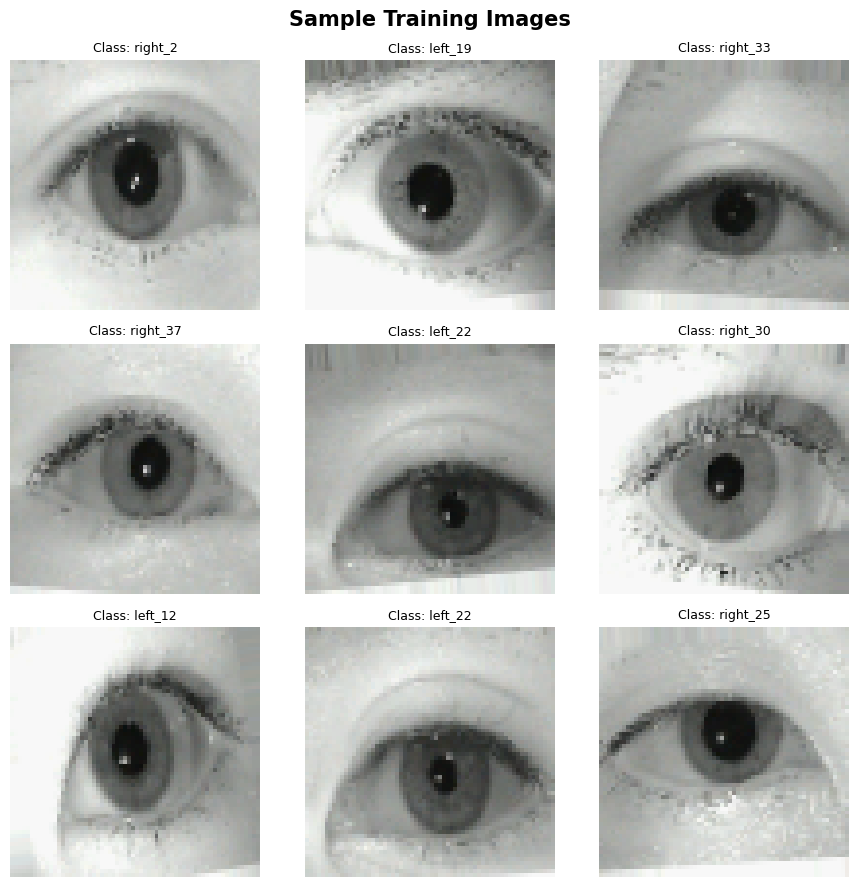

 Do the images look like real iris/eye photos?


In [14]:
images, labels = next(train_small)
class_names = list(train_small.class_indices.keys())

fig, axes = plt.subplots(3, 3, figsize=(9, 9))
fig.suptitle("Sample Training Images", fontsize=15, fontweight='bold')

for i, ax in enumerate(axes.flatten()):
    ax.imshow(images[i])
    class_idx = np.argmax(labels[i])
    ax.set_title(f"Class: {class_names[class_idx]}", fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()
print(" Do the images look like real iris/eye photos?")

In [15]:
# Our first model is a classic Convolutional Neural Network built
# from scratch. It learns features directly from the iris images.
#
# Architecture:
#   Conv → Pool → Conv → Pool → Conv → Pool
#   → Flatten → Dense(256) → Dropout → Dense(NUM_CLASSES)
#
# Input: 64×64 RGB images
# Output: probability for each identity class
# ======================================================================

def build_simple_cnn(num_classes, input_shape=(64, 64, 3)):
    model = Sequential(name="Simple_CNN")

    # Block 1 — learn basic edges and shapes
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same',
                     input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2, 2))

    # Block 2 — learn more complex patterns
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2, 2))

    # Block 3 — learn high-level features
    model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2, 2))

    # Classifier head
    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.4))     # prevents overfitting
    model.add(Dense(num_classes, activation='softmax'))

    return model


cnn_model = build_simple_cnn(NUM_CLASSES)

cnn_model.compile(
    optimizer = 'adam',
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

cnn_model.summary()
print(f"\n Simple CNN built!  Output classes: {NUM_CLASSES}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Simple_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 90)             │        23,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,214,682 (8.45 MB)

 Trainable params: 2,214,234 (8.45 MB)

 Non-trainable params: 448 (1.75 KB)


✅ Simple CNN built!  Output classes: 90


In [16]:
# Our second model uses Transfer Learning.
# MobileNetV2 was pre-trained on 1.4 million ImageNet images.
# We FREEZE all its layers (keep its learned knowledge)
# and only train a small custom head on top for our iris task.
#
# Why this is powerful:
#   • MobileNetV2 already knows how to detect shapes, textures, patterns
#   • We just teach it "these patterns = this iris identity"
#   • Result: much higher accuracy with less training time
#
# Input: 224×224 RGB images
# ======================================================================

def build_mobilenet(num_classes, input_shape=(224, 224, 3)):

    # Load MobileNetV2 WITHOUT its original top (classification) layer
    base = MobileNetV2(
        weights      = 'imagenet',   # pre-trained on ImageNet
        include_top  = False,        # remove original classifier
        input_shape  = input_shape
    )
    base.trainable = False           # freeze all base layers

    print(f"  MobileNetV2 base: {len(base.layers)} layers (all frozen)")

    # Build our custom classifier on top
    x      = base.output
    x      = GlobalAveragePooling2D()(x)      # compress feature maps → vector
    x      = Dense(128, activation='relu')(x)
    x      = Dropout(0.3)(x)
    output = Dense(num_classes, activation='softmax')(x)

    model  = Model(inputs=base.input, outputs=output,
                   name="MobileNetV2_TransferLearning")
    return model


mobilenet_model = build_mobilenet(NUM_CLASSES)

mobilenet_model.compile(
    optimizer = 'adam',
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

mobilenet_model.summary()
print(f"\n✅ MobileNetV2 model built!  Output classes: {NUM_CLASSES}")



9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  MobileNetV2 base: 154 layers (all frozen)


Model: "MobileNetV2_TransferLearning"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,433,562 (9.28 MB)

 Trainable params: 175,578 (685.85 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


✅ MobileNetV2 model built!  Output classes: 90


In [17]:
# We train the Simple CNN for up to 15 epochs.
# EarlyStopping will stop early if validation accuracy stops improving,
# and restore the best weights automatically.
#
# ⏳ Expected time with GPU: 3–8 minutes
# ⏳ Expected time without GPU: 15–30 minutes
# ======================================================================

EPOCHS = 15

early_stop = EarlyStopping(
    monitor             = 'val_accuracy',
    patience            = 4,               # stop if no improvement for 4 epochs
    restore_best_weights= True,
    verbose             = 1
)

print("═" * 55)
print("  🧠 Training Simple CNN ...")
print("═" * 55 + "\n")

history_cnn = cnn_model.fit(
    train_small,
    epochs          = EPOCHS,
    validation_data = val_small,
    callbacks       = [early_stop],
    verbose         = 1
)

cnn_loss, cnn_acc = cnn_model.evaluate(val_small, verbose=0)
print(f"\n✅ Simple CNN Training Complete!")
print(f"   Validation Accuracy : {cnn_acc * 100:.2f}%")
print(f"   Validation Loss     : {cnn_loss:.4f}")

═══════════════════════════════════════════════════════
  🧠 Training Simple CNN ...
═══════════════════════════════════════════════════════

Epoch 1/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 313ms/step - accuracy: 0.0222 - loss: 6.3006 - val_accuracy: 0.0000e+00 - val_loss: 4.5043
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.0611 - loss: 4.4093 - val_accuracy: 0.0111 - val_loss: 5.2485
Epoch 3/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.0528 - loss: 4.2640 - val_accuracy: 0.0111 - val_loss: 6.9340
Epoch 4/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.0583 - loss: 4.2108 - val_accuracy: 0.0222 - val_loss: 7.9004
Epoch 5/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.0889 - loss: 4.1315 - val_accuracy: 0.0333 - val_loss: 8.1581
Epoch 6/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.1167 - loss: 4.0520 - val_accuracy: 0.0333 - val_loss: 8.2045
Epoch 7/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.1056 - loss: 3.9845 - val_

In [18]:

# This usually gets HIGHER accuracy than the Simple CNN because
# it starts with much richer pre-learned features.
#
# ⏳ Expected time with GPU: 5–12 minutes
# ======================================================================

early_stop_mob = EarlyStopping(
    monitor             = 'val_accuracy',
    patience            = 4,
    restore_best_weights= True,
    verbose             = 1
)

print("═" * 55)
print("  🚀 Training MobileNetV2 Transfer Learning ...")
print("═" * 55 + "\n")

history_mob = mobilenet_model.fit(
    train_large,
    epochs          = EPOCHS,
    validation_data = val_large,
    callbacks       = [early_stop_mob],
    verbose         = 1
)

mob_loss, mob_acc = mobilenet_model.evaluate(val_large, verbose=0)
print(f"\n✅ MobileNetV2 Training Complete!")
print(f"   Validation Accuracy : {mob_acc * 100:.2f}%")
print(f"   Validation Loss     : {mob_loss:.4f}")


═══════════════════════════════════════════════════════
  🚀 Training MobileNetV2 Transfer Learning ...
═══════════════════════════════════════════════════════

Epoch 1/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.0194 - loss: 4.7175 - val_accuracy: 0.0667 - val_loss: 4.3551
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 179ms/step - accuracy: 0.0667 - loss: 4.2258 - val_accuracy: 0.1111 - val_loss: 4.0884
Epoch 3/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 247ms/step - accuracy: 0.1111 - loss: 3.9963 - val_accuracy: 0.2222 - val_loss: 3.8109
Epoch 4/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 184ms/step - accuracy: 0.1806 - loss: 3.5424 - val_accuracy: 0.2778 - val_loss: 3.4241
Epoch 5/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 189ms/step - accuracy: 0.2556 - loss: 3.2014 - val_accuracy: 0.3556 - val_loss: 3.0907
Epoch 6/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 219ms/step - accuracy: 0.3111 - loss: 2.8627 - val_accuracy: 0.4778 - val_loss: 2.7261
Epoch 7/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 180ms/step - accuracy: 0.3861 - l

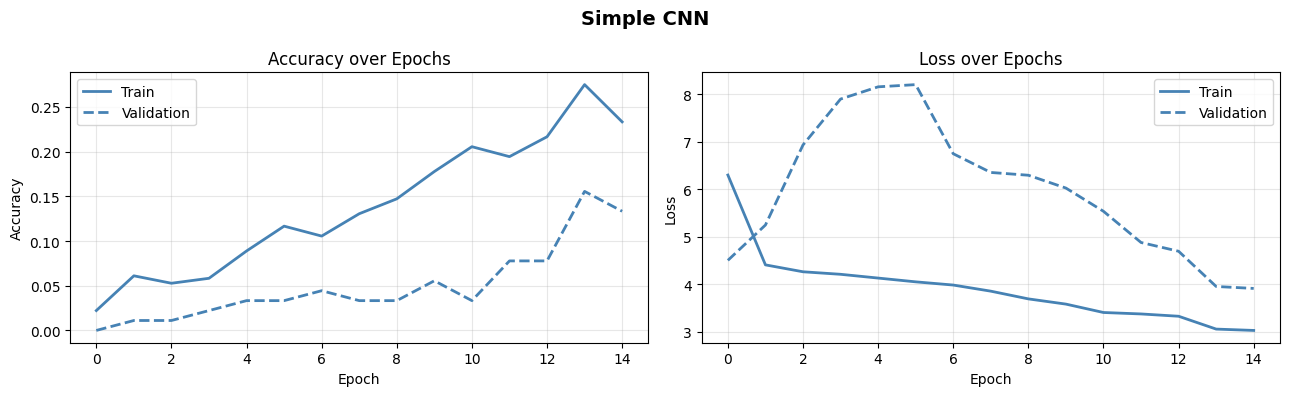

  📊 Saved → simple_cnn_history.png


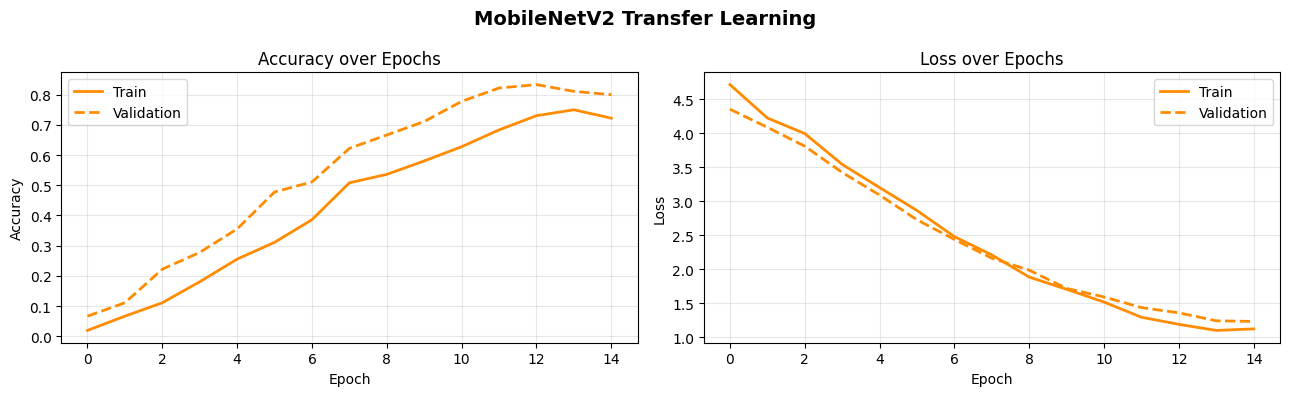

  📊 Saved → mobilenetv2_transfer_learning_history.png


In [19]:
# Visualise how each model learned over time.
# Good signs:
#   • Training and validation accuracy both go UP
#   • They stay CLOSE to each other (no big gap = no overfitting)
# ======================================================================

def plot_history(history, title, color):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    # — Accuracy plot —
    axes[0].plot(history.history['accuracy'],
                 label='Train', color=color, linewidth=2)
    axes[0].plot(history.history['val_accuracy'],
                 label='Validation', color=color,
                 linestyle='--', linewidth=2)
    axes[0].set_title('Accuracy over Epochs')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # — Loss plot —
    axes[1].plot(history.history['loss'],
                 label='Train', color=color, linewidth=2)
    axes[1].plot(history.history['val_loss'],
                 label='Validation', color=color,
                 linestyle='--', linewidth=2)
    axes[1].set_title('Loss over Epochs')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    fname = title.lower().replace(' ', '_') + "_history.png"
    plt.savefig(fname, dpi=120)
    plt.show()
    print(f"  📊 Saved → {fname}")


plot_history(history_cnn, "Simple CNN",                   color='steelblue')
plot_history(history_mob, "MobileNetV2 Transfer Learning", color='darkorange')



════════════════════════════════════════════════════
    FINAL RESULTS
════════════════════════════════════════════════════
  Simple CNN
    Validation Accuracy :   15.56%
    Validation Loss     :  3.9545

  MobileNetV2 Transfer Learning
    Validation Accuracy :   83.33%
    Validation Loss     :  1.3570

   Winner: MobileNetV2  (by 67.78%)
════════════════════════════════════════════════════


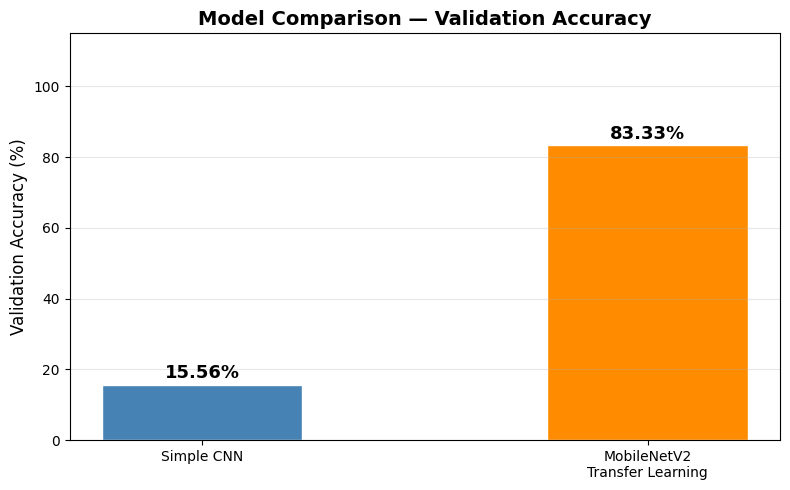

📊 Saved → model_comparison.png


In [20]:
# Print results
print("\n" + "═" * 52)
print("    FINAL RESULTS")
print("═" * 52)
print(f"  Simple CNN")
print(f"    Validation Accuracy : {cnn_acc * 100:>7.2f}%")
print(f"    Validation Loss     : {cnn_loss:>7.4f}")
print()
print(f"  MobileNetV2 Transfer Learning")
print(f"    Validation Accuracy : {mob_acc * 100:>7.2f}%")
print(f"    Validation Loss     : {mob_loss:>7.4f}")
print()
winner = "MobileNetV2" if mob_acc > cnn_acc else "Simple CNN"
diff = abs(mob_acc - cnn_acc) * 100
print(f"   Winner: {winner}  (by {diff:.2f}%)")
print("═" * 52)

# Bar chart
models     = ['Simple CNN', 'MobileNetV2\nTransfer Learning']
accuracies = [cnn_acc * 100, mob_acc * 100]
colors     = ['steelblue', 'darkorange']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models, accuracies, color=colors, width=0.45, edgecolor='white')

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.8,
            f"{acc:.2f}%",
            ha='center', va='bottom',
            fontsize=13, fontweight='bold')

ax.set_ylim(0, 115)
ax.set_ylabel("Validation Accuracy (%)", fontsize=12)
ax.set_title("Model Comparison — Validation Accuracy", fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=120)
plt.show()
print(" Saved → model_comparison.png")

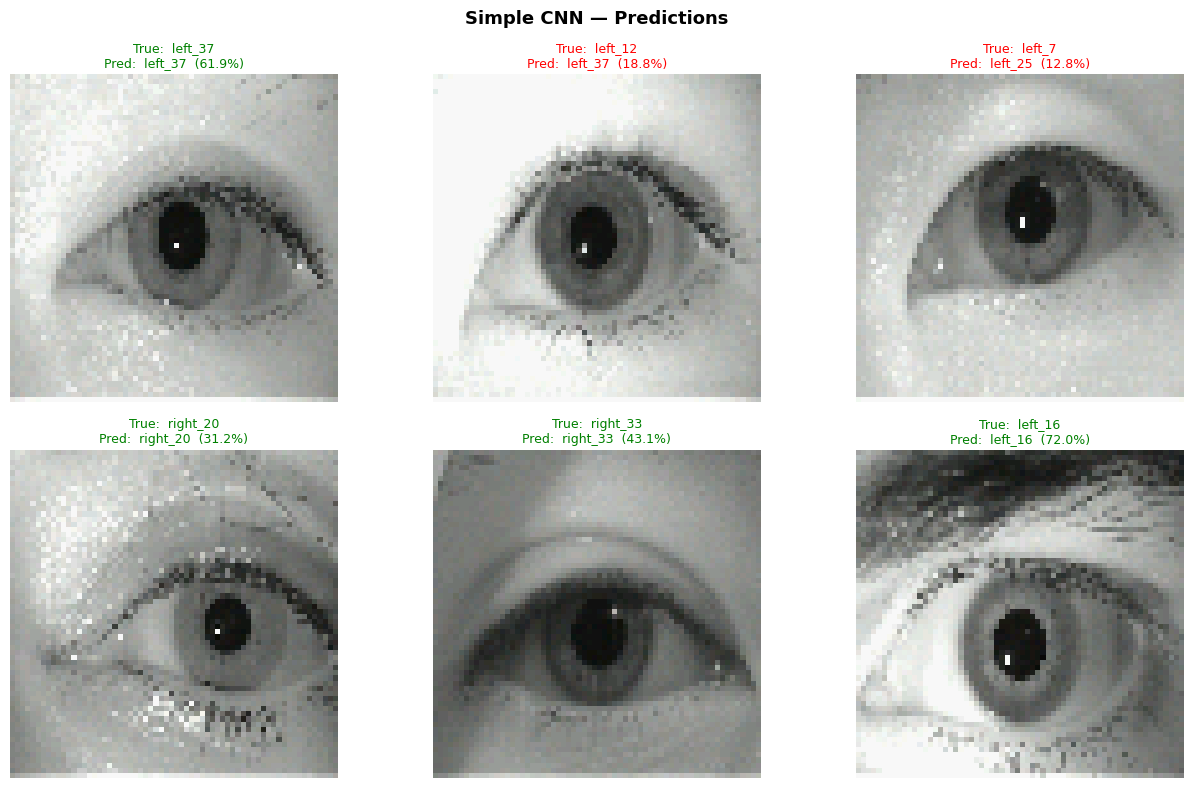

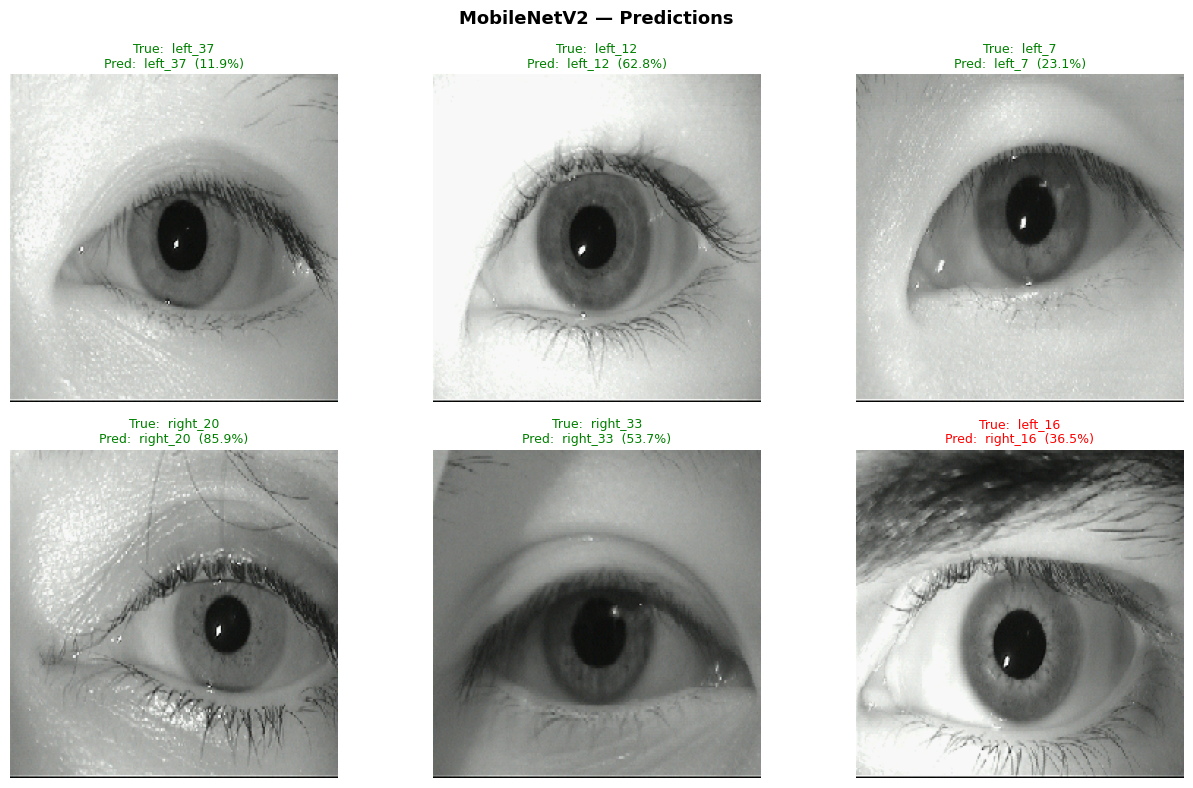

In [21]:
def show_predictions(model, generator, class_names, title, n=6):
    images, labels = next(generator)
    preds  = model.predict(images, verbose=0)

    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(13, 4 * rows))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    for i, ax in enumerate(axes.flatten()):
        if i >= min(n, len(images)):
            ax.axis('off')
            continue
        ax.imshow(images[i])
        true_lbl = class_names[np.argmax(labels[i])]
        pred_lbl = class_names[np.argmax(preds[i])]
        conf     = np.max(preds[i]) * 100
        colour   = 'green' if true_lbl == pred_lbl else 'red'
        ax.set_title(
            f"True:  {true_lbl}\nPred:  {pred_lbl}  ({conf:.1f}%)",
            color=colour, fontsize=9)
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(title.lower().replace(' ', '_') + "_predictions.png", dpi=120)
    plt.show()

show_predictions(cnn_model,       val_small, class_names, "Simple CNN — Predictions")
show_predictions(mobilenet_model, val_large, class_names, "MobileNetV2 — Predictions")

In [22]:
# Cell 16 — Save
cnn_model.save("iris_cnn_model.h5")
mobilenet_model.save("iris_mobilenet_model.h5")
print(" Models saved!")
print("    iris_cnn_model.h5")
print("    iris_mobilenet_model.h5")

 Models saved!
    iris_cnn_model.h5
    iris_mobilenet_model.h5


In [23]:
# Cell 17 — Download
from google.colab import files
files.download('iris_cnn_model.h5')
files.download('iris_mobilenet_model.h5')
print(" Check your Downloads folder!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Check your Downloads folder!
